In [ ]:
from agents import Agent, ItemHelpers, Runner, function_tool


@function_tool
def get_weather(city: str):
    """Get weather by city"""
    # print(city)
    return "30 degrees"


agent = Agent(
    name="Assistant Agent",
    instructions="You are a helpful assistant. Use tools when needed to answer questions",
    tools=[get_weather],
)

stream = Runner.run_streamed(
    agent, "Hello, how are you? what is the weather in the capital of Spain?"
)

async for event in stream.stream_events():
    if event.type == "raw_response_event":
        continue
    elif event.type == "agent_updated_stream_event":
        print("Agent updated to ", event.new_agent.name)
    elif event.type == "run_item_stream_event":
        if event.item.type == "tool_call_item":
            print(event.item.raw_item.to_dict())
        elif event.item.type == "tool_call_output_item":
            print(event.item.output)
        elif event.item.type == "message_output_item":
            print(ItemHelpers.text_message_output(event.item))
    print("=" * 20)

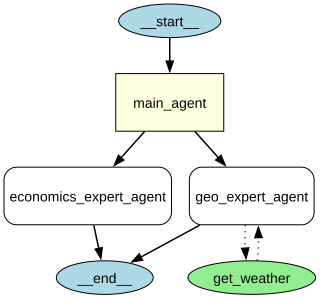

In [ ]:
from agents import Agent, Runner, function_tool, SQLiteSession, trace
from agents.extensions.visualization import draw_graph
from pydantic import BaseModel

session = SQLiteSession("user_12", "ai-memory.db")


class Answer(BaseModel):
    answer: str
    background_explanation: str


@function_tool
def get_weather():
    return "30"


geography_agent = Agent(
    name="geo_expert_agent",
    instructions="You are a expert in geography. you answer questions related to them.",
    handoff_description="Use this to answer geography related questions.",
    tools=[get_weather],
    output_type=Answer,
)

economics_agent = Agent(
    name="economics_expert_agent",
    instructions="You are a expert in economics. you answer questions related to them.",
    handoff_description="Use this to answer economics questions.",
)

main_agent = Agent(
    name="main_agent",
    instructions="You are a user facing agent. Transfer to the agent most capable of answering the user's question.",
    handoffs=[
        economics_agent,
        geography_agent,
    ],
)

draw_graph(main_agent)

In [ ]:
with trace("user_12"):
    result = await Runner.run(
        main_agent,
        "What is the capital of Thailand's northen province?",
        session=session,
    )

print(result.last_agent.name)

print(result.final_output)

geo_expert_agent
answer='Chiang Mai is the capital of Thailand’s northern province region (often referring to Chiang Mai Province).' background_explanation='Thailand’s north is a region made up of several provinces, not one single province. If you mean the main city in northern Thailand, Chiang Mai is the usual answer.'


In [ ]:
await session.add_items([{"role": "user", "content": "I live in Seoul, Korea"}])